<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_05_reg_multivariada_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Regresión multivariada

## Objetivo

Construir un modelo de regresión multivariada para ajustar un plano generado sintéticamente, entender la formulación matricial del problema y resolver la estimación de parámetros mediante gradiente descendente vectorizado.

## Contexto matemático

Supongamos que tenemos $n$ variables explicativas y $m$ observaciones. El modelo lineal multivariado puede escribirse como:

$$
\hat{y} = 	\theta_0 + 	\theta_1 x_1 + 	\theta_2 x_2 + \dots + 	\theta_n x_n.
$$

En forma vectorial:

$$
h_\theta(x) = \theta^T X.
$$

Si $X$ contiene una fila de unos para el sesgo, entonces el costo cuadrático medio puede expresarse como:

$$
J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}
\right)^2.
$$

El objetivo es encontrar los parámetros que minimicen esta función de costo. Para ello, usamos descenso del gradiente:

$$
\theta := \theta - \alpha 
\nabla J(\theta).
$$

## Librerías

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

## 1. Generación de datos

Construimos un conjunto de datos sintético donde la variable objetivo depende linealmente de dos características. Esto nos permite verificar si el método recupera los parámetros esperados.

In [12]:
N = 120
x1 = 2 * np.random.random(N) - 1
x2 = 2 * np.random.random(N) - 1
noise = 0.08 * np.random.randn(N)

y = 0.2 * x1 - 0.5 * x2 + noise

df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})
df.head()

,x1,x2,y
0,-0.250920,0.614880,-0.375501
1,0.901429,0.792183,-0.158686
2,0.463988,-0.363993,0.312653
3,0.197317,-0.779896,0.423585
4,-0.687963,-0.544130,0.066729


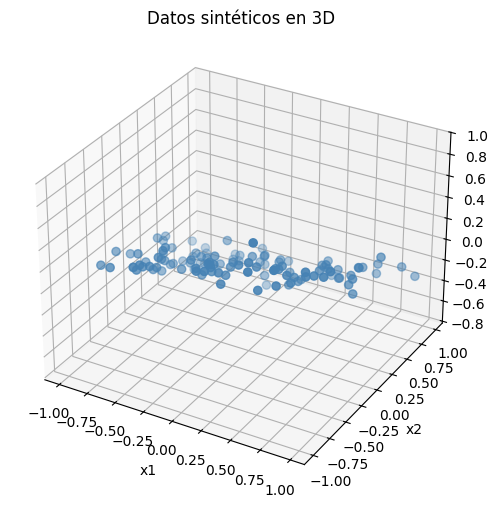

In [13]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['x1'], df['x2'], df['y'], c='steelblue', s=35)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('Datos sintéticos en 3D')
plt.show()

## 2. Formulación matricial

Agregamos una columna de unos para incluir el término independiente y construimos la matriz de diseño.

In [14]:
X = np.c_[np.ones(N), df['x1'].values, df['x2'].values]
Y = df['y'].values.reshape(-1, 1)

print('Dimensión de X:', X.shape)
print('Dimensión de Y:', Y.shape)

theta_inicial = np.random.random((3, 1))
print('Theta inicial:')
print(theta_inicial)

Dimensión de X: (120, 3)
Dimensión de Y: (120, 1)
Theta inicial:
[[0.99050514]
 [0.41261768]
 [0.37201809]]


## 3. Modelo, costo y gradiente

La predicción del modelo se calcula como $h = heta^T X$. La función de costo es el error cuadrático medio y su gradiente vectorizado permite actualizar todos los parámetros a la vez.

In [15]:
def model(theta, X):
    return X @ theta

def costo(h, Y):
    return np.mean((h - Y) ** 2) / 2

def gradiente(theta, X, Y):
    m = X.shape[0]
    h = model(theta, X)
    return (X.T @ (h - Y)) / m

def update_params(theta, X, Y, learning_rate):
    return theta - learning_rate * gradiente(theta, X, Y)

## 4. Descenso del gradiente

Iteramos la actualización de parámetros y registramos la evolución del costo para verificar la convergencia.

In [16]:
theta = np.random.random((3, 1))
learning_rate = 0.08
Niter = 500
J = np.zeros(Niter)

for i in range(Niter):
    h = model(theta, X)
    J[i] = costo(h, Y)
    theta = update_params(theta, X, Y, learning_rate)

print('Theta estimado:')
print(theta.ravel())
print(f'Costo final: {J[-1]:.6f}')

Theta estimado:
[ 0.00193173  0.21243362 -0.52148854]
Costo final: 0.003278


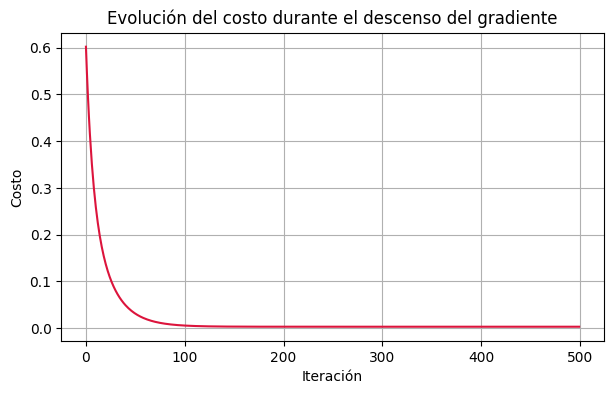

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(J, color='crimson')
plt.xlabel('Iteración')
plt.ylabel('Costo')
plt.title('Evolución del costo durante el descenso del gradiente')
plt.show()

## 5. Comparación con la solución analítica

Para verificar el resultado, comparamos con una regresión lineal de `scikit-learn`. El ajuste debería aproximarse a los coeficientes verdaderos usados para generar los datos.

In [18]:
lin_reg = LinearRegression()
lin_reg.fit(df[['x1', 'x2']], df['y'])

theta_sklearn = np.r_[lin_reg.intercept_, lin_reg.coef_]
print('Theta sklearn:')
print(theta_sklearn)

pred_gd = model(theta, X).ravel()
pred_sk = lin_reg.predict(df[['x1', 'x2']])

rmse_gd = mean_squared_error(df['y'], pred_gd, squared=False)
rmse_sk = mean_squared_error(df['y'], pred_sk, squared=False)
r2_gd = r2_score(df['y'], pred_gd)
r2_sk = r2_score(df['y'], pred_sk)

print(f'RMSE gradiente descendente: {rmse_gd:.6f}')
print(f'RMSE sklearn: {rmse_sk:.6f}')
print(f'R2 gradiente descendente: {r2_gd:.6f}')
print(f'R2 sklearn: {r2_sk:.6f}')

Theta sklearn:
[ 0.00193081  0.21242616 -0.52149804]
RMSE gradiente descendente: 0.080965
RMSE sklearn: 0.080965
R2 gradiente descendente: 0.946689
R2 sklearn: 0.946689


c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


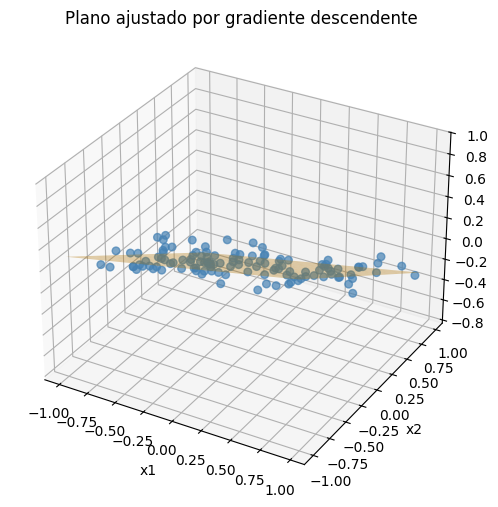

In [19]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['x1'], df['x2'], df['y'], c='steelblue', s=30, alpha=0.7, label='Datos')

grid_x1 = np.linspace(df['x1'].min(), df['x1'].max(), 20)
grid_x2 = np.linspace(df['x2'].min(), df['x2'].max(), 20)
X1g, X2g = np.meshgrid(grid_x1, grid_x2)
Yg = theta[0] + theta[1] * X1g + theta[2] * X2g

ax.plot_surface(X1g, X2g, Yg, alpha=0.35, color='orange')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('Plano ajustado por gradiente descendente')
plt.show()

## 6. Clase para automatizar el proceso

Empaquetamos el algoritmo en una clase para repetir el procedimiento de forma ordenada y reutilizable.

In [20]:
class MultilinearRegresion:
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
        self.Nfeatures = X.shape[1]
        self.m = X.shape[0]
        self.theta = np.random.random((self.Nfeatures, 1))
        self.J_hist = []

    def model(self):
        self.h = self.X @ self.theta
        return self.h

    def costo(self):
        self.J = np.mean((self.h - self.Y) ** 2) / 2
        self.J_hist.append(self.J)
        return self.J

    def update_params(self, learning_rate):
        grad = (self.X.T @ (self.h - self.Y)) / self.m
        self.theta = self.theta - learning_rate * grad

    def fit(self, learning_rate=0.05, Niter=300):
        for _ in range(Niter):
            self.model()
            self.costo()
            self.update_params(learning_rate)
        return self.theta

Theta obtenido con la clase:
[ 0.00193168  0.21243317 -0.52148914]


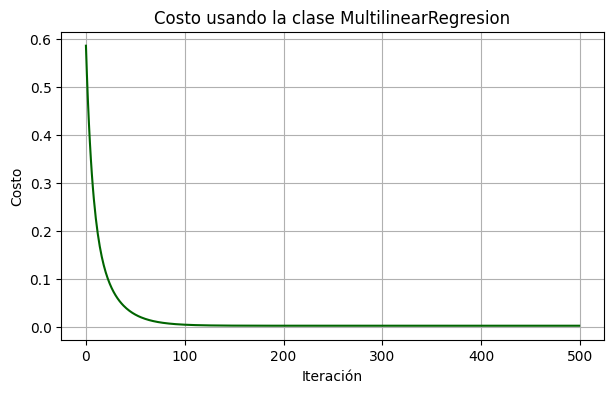

In [21]:
reg = MultilinearRegresion(X, Y)
theta_class = reg.fit(learning_rate=0.08, Niter=500)

print('Theta obtenido con la clase:')
print(theta_class.ravel())

plt.figure(figsize=(7, 4))
plt.plot(reg.J_hist, color='darkgreen')
plt.xlabel('Iteración')
plt.ylabel('Costo')
plt.title('Costo usando la clase MultilinearRegresion')
plt.show()

## Interpretación final

El descenso del gradiente recupera los parámetros del plano generador y el costo disminuye de forma sostenida. La solución aprendida por la clase coincide con la solución matricial y con la regresión lineal de referencia.

La principal lección del laboratorio es que la formulación vectorizada simplifica el cómputo y facilita la implementación de modelos multivariados más generales.